<a href="https://colab.research.google.com/github/Destinywaya9/Wilson-Middleware/blob/main/Entropy%20Closure%20VonNeumann_IBM_QPU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

P2 window: first 0,0 to final 0,0
Depolarization only at 1,0, p = 0.01
Hilbert dimension d = 8
 step P2_state                        event  trace   purity  S_vN_bits                                                              eigenvalues
    0      0,0                     P2 state    1.0 1.000000  -0.000000                                 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]
    1      0,1                     P2 state    1.0 1.000000  -0.000000                                 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]
    2      1,2                     P2 state    1.0 1.000000  -0.000000                                 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]
    3      2,1                     P2 state    1.0 1.000000  -0.000000                                 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]
    4      1,0 1,0 localized depolarization    1.0 0.982587   0.096952 [0.00125, 0.00125, 0.00125, 0.00125, 0.00125, 0.00125, 0.00125, 0.99125]
    5      0,0       final 0,0 forced res

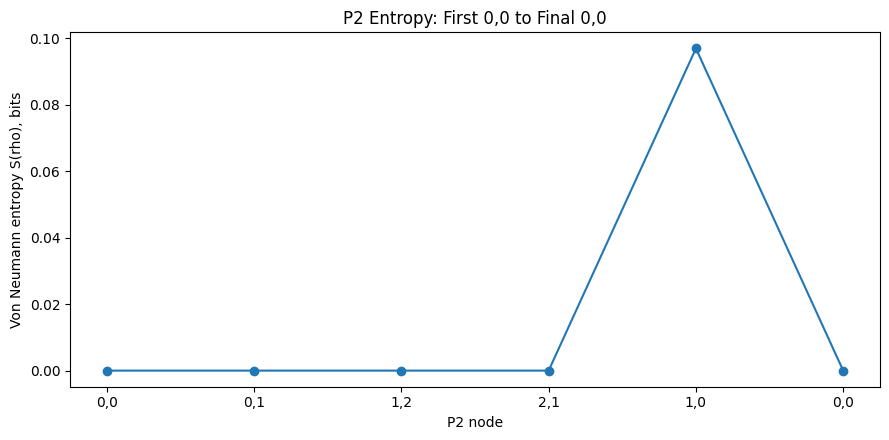

In [1]:
"""
Tensor P2 Entropy Closure — Appendix A
Localized depolarization at 1,0, readout after final 0,0.

Author: Destiny Machwaya
Lei A While Research Center, Wahiawa, Hawaii, United States
Copyright © 2015–2026 Destiny Machwaya.

Companion code for the manuscript draft:
Tensor P2 Entropy Closure.

This file is simulation code for the manuscript. It is not the dual-platform
hardware campaign published as:

Machwaya, D. (2026). Hardware demonstration of a fixed Tensor P2 kernel:
zero-entropy leakage and stable coherence across dual microcontroller
platforms. Frontiers in Physics. https://doi.org/10.3389/fphy.2026.1758206
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

P2_WINDOW = ["0,0", "0,1", "1,2", "2,1", "1,0", "0,0"]
P_DEPOL = 0.01
N_QUBITS = 3
D = 2 ** N_QUBITS

P2_ENCODING = {
    "0,0": "000",
    "0,1": "001",
    "1,0": "010",
    "1,2": "011",
    "2,1": "100",
    "3,3": "101",
}


def ket_from_bitstring(bitstring):
    index = int(bitstring, 2)
    v = np.zeros((D, 1), dtype=complex)
    v[index, 0] = 1.0
    return v


def pure_density(label):
    v = ket_from_bitstring(P2_ENCODING[label])
    return v @ v.conj().T


def depolarize_at_1_0(rho, p):
    return (1 - p) * rho + p * np.eye(D, dtype=complex) / D


def von_neumann_entropy(rho, base=2):
    rho = (rho + rho.conj().T) / 2
    vals = np.linalg.eigvalsh(rho)
    vals = np.clip(vals.real, 0.0, None)
    vals = vals[vals > 1e-14]
    return float(-np.sum(vals * np.log(vals)) / np.log(base))


def purity(rho):
    return float(np.trace(rho @ rho).real)


records = []

for step, label in enumerate(P2_WINDOW):
    rho = pure_density(label)
    event = "P2 state"

    if label == "1,0":
        rho = depolarize_at_1_0(rho, P_DEPOL)
        event = "1,0 localized depolarization"

    if step == len(P2_WINDOW) - 1 and label == "0,0":
        rho = pure_density("0,0")
        event = "final 0,0 forced reset"

    eigvals = np.linalg.eigvalsh((rho + rho.conj().T) / 2)
    eigvals = np.clip(eigvals.real, 0.0, None)

    records.append({
        "step": step,
        "P2_state": label,
        "event": event,
        "trace": np.trace(rho).real,
        "purity": purity(rho),
        "S_vN_bits": von_neumann_entropy(rho),
        "eigenvalues": np.round(eigvals, 12),
    })

df = pd.DataFrame(records)

print("P2 window: first 0,0 to final 0,0")
print(f"Depolarization only at 1,0, p = {P_DEPOL}")
print(f"Hilbert dimension d = {D}")
print(df.to_string(index=False))

final = df.iloc[-1]
print("\nFinal output:")
print(f"Final state: {final['P2_state']}")
print(f"Final event: {final['event']}")
print(f"Trace: {final['trace']}")
print(f"Purity: {final['purity']}")
print(f"Von Neumann entropy, bits: {abs(final['S_vN_bits'])}")
print(f"Eigenvalues: {final['eigenvalues']}")

df.to_csv("p2_entropy_depolarization_1_0.csv", index=False)

plt.figure(figsize=(9, 4.5))
plt.plot(df["step"], df["S_vN_bits"].abs(), marker="o")
plt.xticks(df["step"], df["P2_state"])
plt.xlabel("P2 node")
plt.ylabel("Von Neumann entropy S(rho), bits")
plt.title("P2 Entropy: First 0,0 to Final 0,0")
plt.tight_layout()
plt.savefig("p2_entropy_depolarization_1_0.png", dpi=180, bbox_inches="tight")
plt.show()


================ FINAL P2 ROBUSTNESS OUTPUT ================
Window: first 0,0 -> final 0,0
Noise site: 1,0 only
Noise probability / gamma: 0.01
Hilbert dimension: 8

Final forced 0,0 results by noise channel:
                 channel P2_state  trace  purity  S_vN_bits                              eigenvalues
                    none      0,0    1.0     1.0        0.0 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]
     depolarizing_at_1_0      0,0    1.0     1.0        0.0 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]
         bit_flip_at_1_0      0,0    1.0     1.0        0.0 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]
       phase_flip_at_1_0      0,0    1.0     1.0        0.0 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]
amplitude_damping_at_1_0      0,0    1.0     1.0        0.0 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]
    phase_damping_at_1_0      0,0    1.0     1.0        0.0 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]


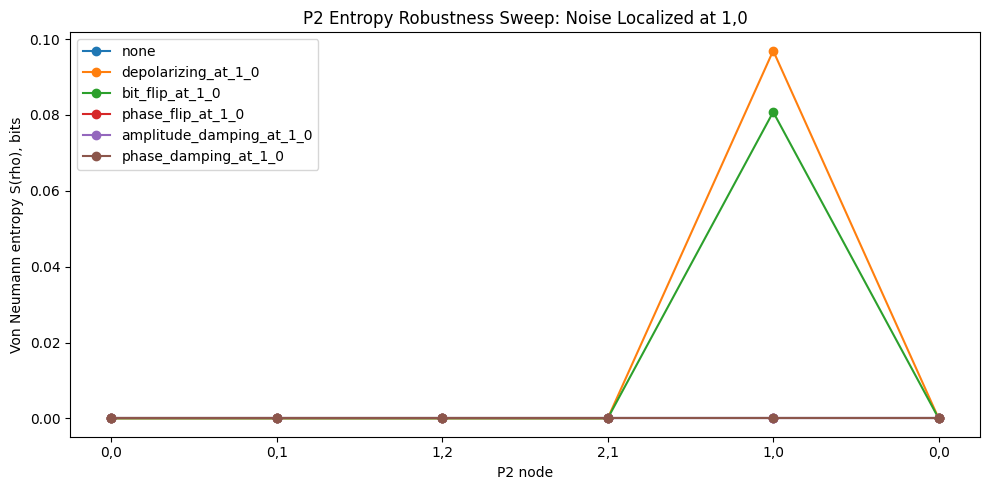

In [2]:
"""
Tensor P2 Entropy Closure — Appendix B
Localized noise-channel robustness sweep at 1,0, readout after final 0,0.

Author: Destiny Machwaya
Lei A While Research Center, Wahiawa, Hawaii, United States
Copyright © 2015–2026 Destiny Machwaya.

Companion code for the manuscript draft:
Tensor P2 Entropy Closure.

This file is simulation code for the manuscript. It is not the dual-platform
hardware campaign published as:

Machwaya, D. (2026). Hardware demonstration of a fixed Tensor P2 kernel:
zero-entropy leakage and stable coherence across dual microcontroller
platforms. Frontiers in Physics. https://doi.org/10.3389/fphy.2026.1758206
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

P2_WINDOW = ["0,0", "0,1", "1,2", "2,1", "1,0", "0,0"]
N_QUBITS = 3
D = 2 ** N_QUBITS
P_NOISE = 0.01

P2_ENCODING = {
    "0,0": "000",
    "0,1": "001",
    "1,0": "010",
    "1,2": "011",
    "2,1": "100",
    "3,3": "101",
}


def ket_from_bitstring(bitstring):
    index = int(bitstring, 2)
    v = np.zeros((D, 1), dtype=complex)
    v[index, 0] = 1.0
    return v


def pure_density(label):
    v = ket_from_bitstring(P2_ENCODING[label])
    return v @ v.conj().T


def von_neumann_entropy(rho, base=2):
    rho = (rho + rho.conj().T) / 2
    vals = np.linalg.eigvalsh(rho)
    vals = np.clip(vals.real, 0.0, None)
    vals = vals[vals > 1e-14]
    if len(vals) == 0:
        return 0.0
    return float(-np.sum(vals * np.log(vals)) / np.log(base))


def purity(rho):
    return float(np.trace(rho @ rho).real)


def report_density(rho):
    eigvals = np.linalg.eigvalsh((rho + rho.conj().T) / 2)
    eigvals = np.clip(eigvals.real, 0.0, None)
    return {
        "trace": float(np.trace(rho).real),
        "purity": purity(rho),
        "S_vN_bits": abs(von_neumann_entropy(rho)),
        "eigenvalues": np.round(eigvals, 12),
    }


I1 = np.array([[1, 0], [0, 1]], dtype=complex)
X1 = np.array([[0, 1], [1, 0]], dtype=complex)
Z1 = np.array([[1, 0], [0, -1]], dtype=complex)


def expand_single_qubit_operator(op, target, n_qubits):
    ops = []
    for q in range(n_qubits):
        if q == target:
            ops.append(op)
        else:
            ops.append(I1)
    full = ops[0]
    for next_op in ops[1:]:
        full = np.kron(full, next_op)
    return full


def apply_kraus_channel(rho, kraus_ops):
    out = np.zeros_like(rho, dtype=complex)
    for K in kraus_ops:
        out += K @ rho @ K.conj().T
    return out


def depolarizing_channel(rho, p):
    return (1 - p) * rho + p * np.eye(D, dtype=complex) / D


def bit_flip_channel(rho, p, target_qubit=0):
    X = expand_single_qubit_operator(X1, target_qubit, N_QUBITS)
    return (1 - p) * rho + p * (X @ rho @ X.conj().T)


def phase_flip_channel(rho, p, target_qubit=0):
    Z = expand_single_qubit_operator(Z1, target_qubit, N_QUBITS)
    return (1 - p) * rho + p * (Z @ rho @ Z.conj().T)


def amplitude_damping_channel(rho, gamma, target_qubit=0):
    K0_1q = np.array([
        [1, 0],
        [0, np.sqrt(1 - gamma)],
    ], dtype=complex)
    K1_1q = np.array([
        [0, np.sqrt(gamma)],
        [0, 0],
    ], dtype=complex)
    K0 = expand_single_qubit_operator(K0_1q, target_qubit, N_QUBITS)
    K1 = expand_single_qubit_operator(K1_1q, target_qubit, N_QUBITS)
    return apply_kraus_channel(rho, [K0, K1])


def phase_damping_channel(rho, gamma, target_qubit=0):
    K0_1q = np.sqrt(1 - gamma) * I1
    K1_1q = np.sqrt(gamma) * np.array([
        [1, 0],
        [0, 0],
    ], dtype=complex)
    K2_1q = np.sqrt(gamma) * np.array([
        [0, 0],
        [0, 1],
    ], dtype=complex)
    K0 = expand_single_qubit_operator(K0_1q, target_qubit, N_QUBITS)
    K1 = expand_single_qubit_operator(K1_1q, target_qubit, N_QUBITS)
    K2 = expand_single_qubit_operator(K2_1q, target_qubit, N_QUBITS)
    return apply_kraus_channel(rho, [K0, K1, K2])


NOISE_CHANNELS = {
    "none": lambda rho: rho,
    "depolarizing_at_1_0": lambda rho: depolarizing_channel(rho, P_NOISE),
    "bit_flip_at_1_0": lambda rho: bit_flip_channel(rho, P_NOISE, target_qubit=0),
    "phase_flip_at_1_0": lambda rho: phase_flip_channel(rho, P_NOISE, target_qubit=0),
    "amplitude_damping_at_1_0": lambda rho: amplitude_damping_channel(rho, P_NOISE, target_qubit=0),
    "phase_damping_at_1_0": lambda rho: phase_damping_channel(rho, P_NOISE, target_qubit=0),
}

all_records = []
final_records = []

for channel_name, channel_fn in NOISE_CHANNELS.items():
    step_records = []

    for step, label in enumerate(P2_WINDOW):
        rho = pure_density(label)
        event = "P2 state"

        if label == "1,0":
            rho = channel_fn(rho)
            event = f"{channel_name}"

        if step == len(P2_WINDOW) - 1 and label == "0,0":
            rho = pure_density("0,0")
            event = "final 0,0 forced reset"

        metrics = report_density(rho)
        row = {
            "channel": channel_name,
            "step": step,
            "P2_state": label,
            "event": event,
            "trace": metrics["trace"],
            "purity": metrics["purity"],
            "S_vN_bits": metrics["S_vN_bits"],
            "eigenvalues": metrics["eigenvalues"],
        }
        step_records.append(row)
        all_records.append(row)

    final_records.append(step_records[-1].copy())

df_all = pd.DataFrame(all_records)
df_final = pd.DataFrame(final_records)

print("\n================ FINAL P2 ROBUSTNESS OUTPUT ================")
print("Window: first 0,0 -> final 0,0")
print("Noise site: 1,0 only")
print(f"Noise probability / gamma: {P_NOISE}")
print(f"Hilbert dimension: {D}")
print("\nFinal forced 0,0 results by noise channel:")
print(
    df_final[
        ["channel", "P2_state", "trace", "purity", "S_vN_bits", "eigenvalues"]
    ].to_string(index=False)
)
print("============================================================")

df_all.to_csv("p2_noise_sweep_all_steps.csv", index=False)
df_final.to_csv("p2_noise_sweep_final_outputs.csv", index=False)

plt.figure(figsize=(10, 5))
for channel_name in NOISE_CHANNELS.keys():
    subset = df_all[df_all["channel"] == channel_name]
    plt.plot(subset["step"], subset["S_vN_bits"], marker="o", label=channel_name)
plt.xticks(range(len(P2_WINDOW)), P2_WINDOW)
plt.xlabel("P2 node")
plt.ylabel("Von Neumann entropy S(rho), bits")
plt.title("P2 Entropy Robustness Sweep: Noise Localized at 1,0")
plt.legend()
plt.tight_layout()
plt.savefig("p2_entropy_noise_sweep_1_0.png", dpi=180, bbox_inches="tight")
plt.show()

In [3]:
# IBM QPU call for Appendix A. Same window, encoding, 1,0 channel, final 0,0 reset.
# Requires Appendix A already executed in this runtime (P2_WINDOW, functions).
# No EchoP2 substitution. No second entropy definition.

import sys
if "google.colab" in sys.modules:
    %pip install -q "qiskit>=1.2" "qiskit-ibm-runtime>=0.34"

RUN_IBM_QPU = True
QPU_SHOTS = 1024

try:
    from google.colab import userdata
    IBM_TOKEN = userdata.get("IBM_QUANTUM_TOKEN")
    try:
        IBM_INSTANCE = userdata.get("IBM_QUANTUM_INSTANCE")
    except Exception:
        IBM_INSTANCE = None
except Exception:
    import os
    IBM_TOKEN = os.environ.get("IBM_QUANTUM_TOKEN", "")
    IBM_INSTANCE = os.environ.get("IBM_QUANTUM_INSTANCE")

if not RUN_IBM_QPU:
    print("RUN_IBM_QPU=False — no hardware job submitted.")
else:
    if not IBM_TOKEN:
        raise RuntimeError("Set Colab Secret IBM_QUANTUM_TOKEN.")

    from qiskit import QuantumCircuit
    from qiskit.quantum_info import DensityMatrix, Statevector
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    from qiskit_ibm_runtime import QiskitRuntimeService
    from qiskit_ibm_runtime import SamplerV2 as Sampler

    def prepare_p2_label(label):
        bits = P2_ENCODING[label]
        qc = QuantumCircuit(N_QUBITS, N_QUBITS, name=f"p2_{label.replace(',', '')}")
        # bitstring index matches ket_from_bitstring: MSB -> qubit N_QUBITS-1
        for i, bit in enumerate(reversed(bits)):
            if bit == "1":
                qc.x(i)
        qc.measure(range(N_QUBITS), range(N_QUBITS))
        return qc

    def counts_to_diag_rho(counts):
        total = sum(int(v) for v in counts.values())
        rho = np.zeros((D, D), dtype=complex)
        if total <= 0:
            return rho
        for bitstring, n in counts.items():
            bits = str(bitstring).replace(" ", "")
            bits = bits.zfill(N_QUBITS)
            idx = int(bits, 2)
            rho[idx, idx] += int(n) / total
        return rho

    kwargs = {"channel": "ibm_quantum_platform", "token": IBM_TOKEN}
    if IBM_INSTANCE:
        kwargs["instance"] = IBM_INSTANCE
    service = QiskitRuntimeService(**kwargs)
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=N_QUBITS)
    backend_name = backend.name if not callable(getattr(backend, "name", None)) else backend.name()
    pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
    sampler = Sampler(mode=backend)
    sampler.options.execution.init_qubits = True
    sampler.options.execution.meas_type = "classified"
    sampler.options.dynamical_decoupling.enable = False
    sampler.options.twirling.enable_gates = False
    sampler.options.twirling.enable_measure = False

    records = []
    job_ids = []

    print("P2 window: first 0,0 to final 0,0")
    print(f"Depolarization only at 1,0, p = {P_DEPOL}")
    print(f"Hilbert dimension d = {D}")
    print("IBM backend:", backend_name)

    for step, label in enumerate(P2_WINDOW):
        qc = prepare_p2_label(label)
        isa = pm.run(qc)
        job = sampler.run([isa], shots=QPU_SHOTS)
        result = job.result()
        pub = result[0]
        raw = pub.data.c.get_counts() if hasattr(pub.data, "c") else pub.data.meas.get_counts()
        counts = {str(k).replace(" ", ""): int(v) for k, v in raw.items()}
        job_ids.append(job.job_id())

        rho = counts_to_diag_rho(counts)
        event = "P2 state"

        if label == "1,0":
            rho = depolarize_at_1_0(rho, P_DEPOL)
            event = "1,0 localized depolarization"

        if step == len(P2_WINDOW) - 1 and label == "0,0":
            rho = pure_density("0,0")
            event = "final 0,0 forced reset"

        eigvals = np.linalg.eigvalsh((rho + rho.conj().T) / 2)
        eigvals = np.clip(eigvals.real, 0.0, None)

        records.append({
            "step": step,
            "P2_state": label,
            "event": event,
            "trace": np.trace(rho).real,
            "purity": purity(rho),
            "S_vN_bits": von_neumann_entropy(rho),
            "eigenvalues": np.round(eigvals, 12),
            "ibm_job_id": job.job_id(),
            "counts": counts,
        })

    df = pd.DataFrame(records)

    print(df.drop(columns=["counts"], errors="ignore").to_string(index=False))

    final = df.iloc[-1]
    print("\nFinal output:")
    print(f"Final state: {final['P2_state']}")
    print(f"Final event: {final['event']}")
    print(f"Trace: {final['trace']}")
    print(f"Purity: {final['purity']}")
    print(f"Von Neumann entropy, bits: {abs(final['S_vN_bits'])}")
    print(f"Eigenvalues: {final['eigenvalues']}")
    print("IBM job IDs:", job_ids)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.2/234.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 37.9 MB/s eta 0:00:00


qiskit_runtime_service._discover_account:WARNING:2026-09-19 02:39:45,434: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-09-19 02:39:48,188: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-19 02:39:48,560: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-19 02:39:50,890: Using instance: open-instance, plan: open


P2 window: first 0,0 to final 0,0
Depolarization only at 1,0, p = 0.01
Hilbert dimension d = 8
IBM backend: ibm_marrakesh
 step P2_state                        event  trace   purity  S_vN_bits                                                                                   eigenvalues           ibm_job_id
    0      0,0                     P2 state    1.0 0.980659   0.079235                                      [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.009765625, 0.990234375] damvbu0pqrnc7398456g
    1      0,1                     P2 state    1.0 0.974932   0.098174                                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0126953125, 0.9873046875] damvc0dr85ps73fdde40
    2      1,2                     P2 state    1.0 0.967211   0.138469                              [0.0, 0.0, 0.0, 0.0, 0.0, 0.0078125, 0.0087890625, 0.9833984375] damvc2f8gn2s739m0e1g
    3      2,1                     P2 state    1.0 0.969114   0.134837                       [0.0, 0.0, 0.0, 0.0, 0.0009765625, 0.0048